<a href="https://colab.research.google.com/github/Murad460/Data_Science_Projects/blob/main/top_insta_influencers_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
# Load the dataset
df = pd.read_csv('top_insta_influencers_data.csv')
# Quick inspection of data

In [29]:
df.sample(5)

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
89,90,ladygaga,83,3.6k,53.2m,1.4m,1.02%,531.6k,5.1b,United States
86,87,beingsalmankhan,76,1.2k,53.5m,1.4m,1.33%,693.9k,1.6b,India
7,8,beyonce,92,2.0k,272.8m,3.6m,0.76%,2.0m,7.4b,United States
196,197,nancyajram,81,3.8k,33.2m,390.4k,0.64%,208.0k,1.5b,France
166,167,parineetichopra,84,1.3k,37.4m,505.7k,0.68%,246.9k,672.1m,NaN


In [30]:
def convert_units(value):
    if isinstance(value, str):
        value = value.lower().replace(',', '')
        if 'k' in value:
            return float(value.replace('k','')) * 1_000
        elif 'm' in value:
            return float(value.replace('m','')) * 1_000_000
        elif 'b' in value:
            return float(value.replace('b','')) * 1_000_000_000
        elif '%' in value:
            return float(value.replace('%',''))
    return value

# Apply cleaning
for col in ["posts","followers","avg_likes","60_day_eng_rate","new_post_avg_like","total_likes"]:
    df[col] = df[col].apply(convert_units)

# Final cleaned dataframe
print(df)

     rank channel_info  influence_score   posts    followers  avg_likes  \
0       1    cristiano               92  3300.0  475800000.0  8700000.0   
1       2  kyliejenner               91  6900.0  366200000.0  8300000.0   
2       3     leomessi               90   890.0  357300000.0  6800000.0   
3       4  selenagomez               93  1800.0  342700000.0  6200000.0   
4       5      therock               91  6800.0  334100000.0  1900000.0   
..    ...          ...              ...     ...          ...        ...   
195   196    iambeckyg               71  2300.0   33200000.0   623800.0   
196   197   nancyajram               81  3800.0   33200000.0   390400.0   
197   198  luansantana               79   770.0   33200000.0   193300.0   
198   199    nickjonas               78  2300.0   33000000.0   719600.0   
199   200    raisa6690               80  4200.0   32800000.0   232200.0   

     60_day_eng_rate new_post_avg_like   total_likes        country  
0               1.39         

In [31]:
df.dtypes

,0
rank,int64
channel_info,object
influence_score,int64
posts,float64
followers,float64
avg_likes,float64
60_day_eng_rate,float64
new_post_avg_like,object
total_likes,float64
country,object


In [32]:
print(df.info())
print(df.describe())
# Drop any duplicate rows if present
df.drop_duplicates(inplace=True)
# Handle missing values
# Fill missing numerical values with median, and categorical
# with mode:
for column in df.columns:
  if df[column].dtype == 'object':
    df[column].fillna(df[column].mode()[0], inplace=True)
  else:
    df[column].fillna(df[column].median(), inplace=True)
# Convert necessary columns to appropriate data types
df['followers'] = df['followers'].astype(int)
df['posts'] = df['posts'].astype(int)
df['total_likes'] = df['total_likes'].astype(int)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rank               200 non-null    int64  
 1   channel_info       200 non-null    object 
 2   influence_score    200 non-null    int64  
 3   posts              200 non-null    float64
 4   followers          200 non-null    float64
 5   avg_likes          200 non-null    float64
 6   60_day_eng_rate    199 non-null    float64
 7   new_post_avg_like  200 non-null    object 
 8   total_likes        200 non-null    float64
 9   country            138 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 15.8+ KB
None
             rank  influence_score         posts     followers     avg_likes  \
count  200.000000       200.000000    200.000000  2.000000e+02  2.000000e+02   
mean   100.500000        81.820000   3499.850000  7.740950e+07  1.787104e+06   
std     57.

/tmp/ipython-input-1179654075.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(), inplace=True)
/tmp/ipython-input-1179654075.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [33]:
# Display summary statistics for numeric columns
print(df[['influence_score', 'followers', 'avg_likes',
'60_day_eng_rate', 'new_post_avg_like']].describe())

       influence_score     followers     avg_likes  60_day_eng_rate
count       200.000000  2.000000e+02  2.000000e+02       200.000000
mean         81.820000  7.740950e+07  1.787104e+06         1.896900
std           8.878159  7.368727e+07  2.193359e+06         3.322129
min          22.000000  3.280000e+07  6.510000e+04         0.010000
25%          80.000000  4.000000e+07  5.044000e+05         0.410000
50%          84.000000  5.005000e+07  1.100000e+06         0.880000
75%          86.000000  6.890000e+07  2.100000e+06         2.032500
max          93.000000  4.758000e+08  1.540000e+07        26.410000


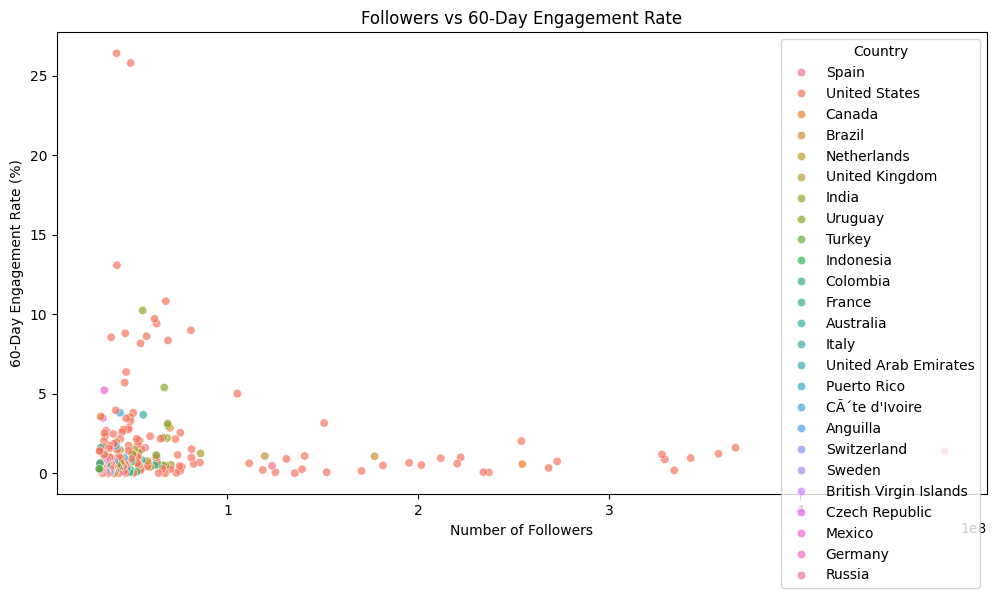

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='followers', y='60_day_eng_rate',
hue='country', alpha=0.7)
plt.title('Followers vs 60-Day Engagement Rate')
plt.xlabel('Number of Followers')
plt.ylabel('60-Day Engagement Rate (%)')
plt.legend(title='Country')
plt.show()

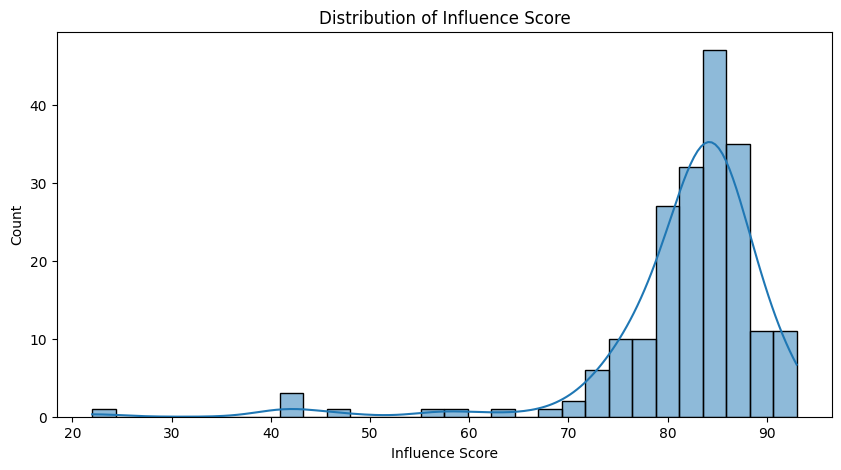

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(df['influence_score'], bins=30, kde=True)
plt.title('Distribution of Influence Score')
plt.xlabel('Influence Score')
plt.show()

/tmp/ipython-input-1511601433.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values,


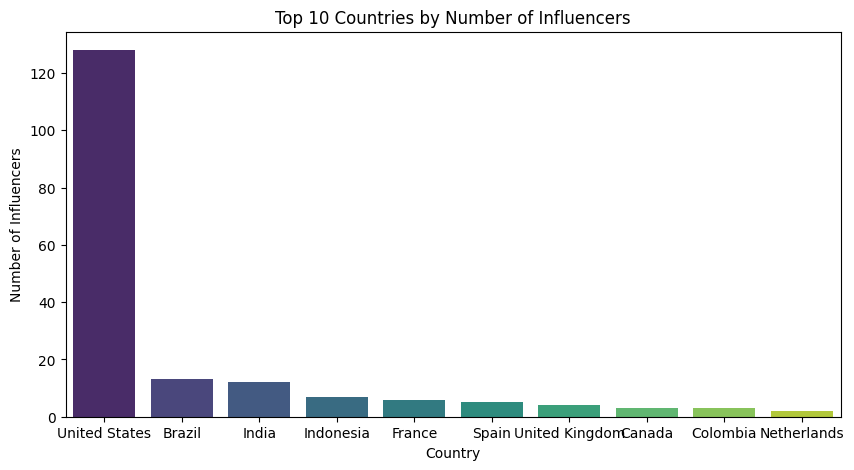

In [36]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.index, y=top_countries.values,
palette="viridis")
plt.title('Top 10 Countries by Number of Influencers')
plt.xlabel('Country')
plt.ylabel('Number of Influencers')
plt.show()

In [37]:
# Creating engagement-related features
df['like_follower_ratio'] = df['total_likes'] / df['followers']
df['post_follower_ratio'] = df['posts'] / df['followers']
df['avg_likes_ratio'] = df['avg_likes'] / df['followers']


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Define feature columns and target variable
X = df[['followers', 'avg_likes', '60_day_eng_rate',
'new_post_avg_like', 'like_follower_ratio',
'post_follower_ratio']]
y = df['influence_score']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Initialize and train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100,
random_state=42)
model.fit(X_train_scaled, y_train)
# Predictions and evaluation
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 171.57413
R^2 Score: -0.014814953920542884


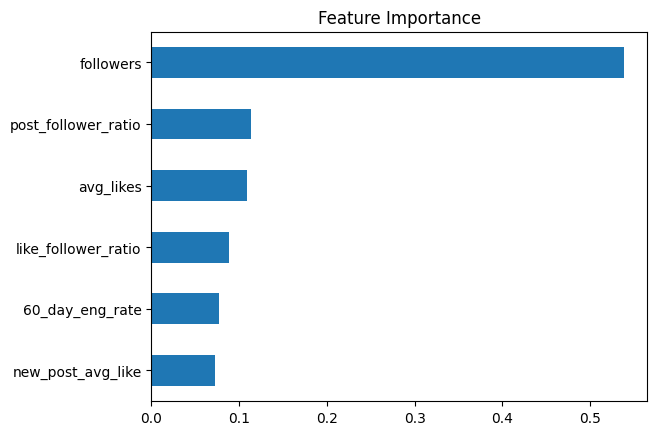

In [39]:
# Display feature importances
feature_importances = pd.Series(model.feature_importances_,
index=X.columns)
feature_importances.sort_values().plot(kind='barh',
title='Feature Importance')
plt.show()

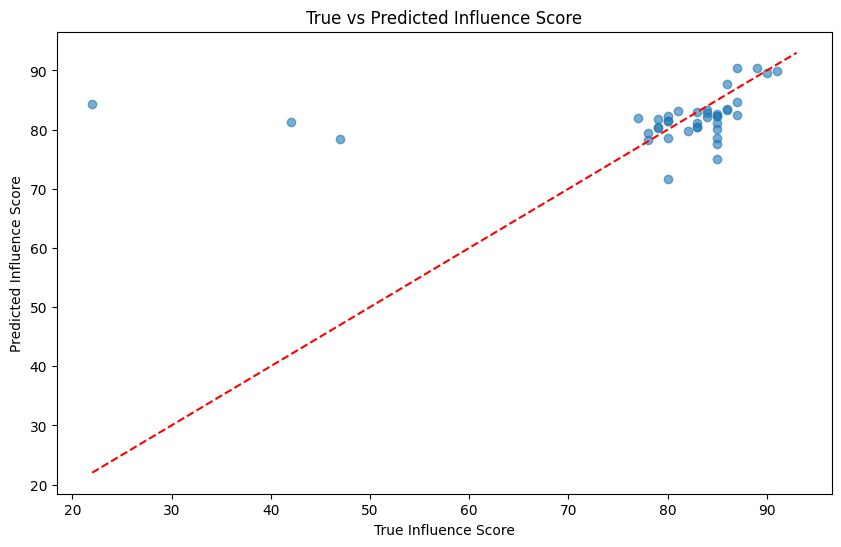

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--',
color='red')
plt.xlabel('True Influence Score')
plt.ylabel('Predicted Influence Score')
plt.title('True vs Predicted Influence Score')
plt.show()